<a href="https://colab.research.google.com/github/Dulina77/VehiclePricePrediction/blob/main/VehicleSales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
data = pd.read_csv("/content/car_price_dataset.csv")
data

,Unnamed: 0,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Date,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price
0,0,AUDI,A1,2016,990.0,Automatic,Petrol,99000.0,Gampaha,2025-02-05,No Leasing,USED,Available,Available,Available,Available,100.00
1,1,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2025-01-14,No Leasing,USED,Available,Available,Available,Available,97.00
2,2,AUDI,A1,2018,1000.0,Automatic,Petrol,77000.0,Dehiwala-Mount-Lavinia,2025-01-23,No Leasing,USED,Available,Available,Available,Available,98.50
3,3,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Negombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,107.00
4,4,AUDI,A1,2017,1000.0,Automatic,Petrol,88000.0,Colombo,2024-12-21,No Leasing,USED,Available,Available,Available,Available,99.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9783,9784,ZOTYE,Z100,2018,1000.0,Manual,Petrol,77000.0,Dambulla,2024-12-16,No Leasing,USED,Available,Available,Available,Available,27.50
9784,9785,ZOTYE,Z100,2019,998.0,Manual,Petrol,66000.0,Nittambuwa,2024-12-12,No Leasing,USED,Available,Available,Available,Available,29.00
9785,9786,ZOTYE,Z100,2017,1000.0,Manual,Petrol,88000.0,Anuradapura,2024-12-04,No Leasing,USED,Available,Available,Available,Available,27.50
9786,9787,ZOTYE,ZOTYE,2017,1300.0,Manual,Petrol,88000.0,Gampaha,2025-01-13,No Leasing,USED,Available,Available,Not_Available,Available,8.75


In [5]:
data.isna().sum()

,0
Unnamed: 0,0
Brand,0
Model,0
YOM,0
Engine (cc),0
Gear,0
Fuel Type,0
Millage(KM),0
Town,0
Date,0


In [7]:
data.dtypes

,0
Unnamed: 0,int64
Brand,object
Model,object
YOM,int64
Engine (cc),float64
Gear,object
Fuel Type,object
Millage(KM),float64
Town,object
Date,object


In [9]:
data['Date'] = pd.to_datetime(data['Date'])
data.dtypes

,0
Unnamed: 0,int64
Brand,object
Model,object
YOM,int64
Engine (cc),float64
Gear,object
Fuel Type,object
Millage(KM),float64
Town,object
Date,datetime64[ns]


In [14]:
data.duplicated().sum()

np.int64(0)

In [19]:
data = data.drop(columns=['Unnamed: 0'])

In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [20]:
data.columns


Index(['Brand', 'Model', 'YOM', 'Engine (cc)', 'Gear', 'Fuel Type',
       'Millage(KM)', 'Town', 'Date', 'Leasing', 'Condition', 'AIR CONDITION',
       'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW', 'Price'],
      dtype='object')

In [22]:
labelEncoder = LabelEncoder()

categorical_cols = ['Brand', 'Model', 'YOM', 'Engine (cc)', 'Gear', 'Fuel Type','Brand', 'Model', 'YOM', 'Engine (cc)', 'Gear', 'Fuel Type']
data_encoded = pd.DataFrame()

for i in categorical_cols:
  data_encoded[f"{i}_encoded"] = labelEncoder.fit_transform(data[i])


In [25]:
data_encoded['Millage(KM)'] = data['Millage(KM)']
data_encoded['Price'] = data['Price']
data_encoded

,Brand_encoded,Model_encoded,YOM_encoded,Engine (cc)_encoded,Gear_encoded,Fuel Type_encoded,Millage(KM),Price
0,0,86,53,55,0,3,99000.0,100.00
1,0,86,54,61,0,3,88000.0,97.00
2,0,86,55,61,0,3,77000.0,98.50
3,0,86,54,61,0,3,88000.0,107.00
4,0,86,54,61,0,3,88000.0,99.50
...,...,...,...,...,...,...,...,...
9783,49,1550,55,61,1,3,77000.0,27.50
9784,49,1550,56,59,1,3,66000.0,29.00
9785,49,1550,54,61,1,3,88000.0,27.50
9786,49,1554,54,104,1,3,88000.0,8.75


In [27]:
correlation = data_encoded.corr()
print(correlation)

                     Brand_encoded  Model_encoded  YOM_encoded  \
Brand_encoded             1.000000       0.052258     0.086309   
Model_encoded             0.052258       1.000000     0.123838   
YOM_encoded               0.086309       0.123838     1.000000   
Engine (cc)_encoded      -0.180515      -0.283102    -0.398765   
Gear_encoded             -0.035150      -0.142213    -0.410124   
Fuel Type_encoded         0.038306       0.066852     0.123220   
Millage(KM)              -0.087155      -0.123699    -0.999757   
Price                    -0.066912      -0.045214     0.508513   

                     Engine (cc)_encoded  Gear_encoded  Fuel Type_encoded  \
Brand_encoded                  -0.180515     -0.035150           0.038306   
Model_encoded                  -0.283102     -0.142213           0.066852   
YOM_encoded                    -0.398765     -0.410124           0.123220   
Engine (cc)_encoded             1.000000     -0.097619          -0.363836   
Gear_encoded        

In [28]:
import seaborn as sns

<Axes: >

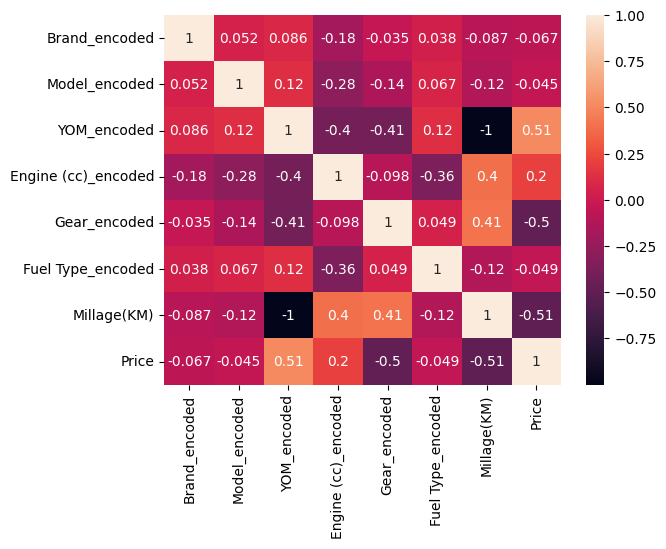

In [29]:
sns.heatmap(correlation, annot=True)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [34]:
X1 = data_encoded.drop(columns=['Price'])
y1 = data_encoded['Price']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=1, test_size=0.3)

LR_model_1 = LinearRegression()
LR_model_1.fit(X1_train, y1_train)

LinearRegression()

In [36]:
y1_pred = LR_model_1.predict(X1_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [40]:
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
r2 = r2_score(y1_test, y1_pred)

print("Mean Absolute Error = ", mae)
print("Mean Squared Error", mse)
print("r2 Score", r2)

Mean Absolute Error =  18.24370210591084
Mean Squared Error 1163.289660965744
r2 Score 0.4536602318184886


In [43]:
data_encoded['Price'].describe()

,Price
count,9788.000000
mean,53.464275
std,43.625049
min,2.650000
25%,26.250000
50%,43.000000
75%,69.750000
max,790.000000
